# 00 — R3 Market Overview (Start Here)

**If you are new to this project, read this notebook first.**

This is a beginner-friendly tour of the IMC Prosperity 4 Round 3 market and the
data we have to work with. No quant background assumed. Each chart has a
plain-English caption telling you what to take away from it.

A few terms used throughout, defined once:

- **Mid-price** ("mid"): the midpoint between the best buy price (bid) and best
  sell price (ask). A rough estimate of "fair value" at any moment.
- **Spread**: ask minus bid. Wide spread = the market is uncertain or thin;
  narrow spread = tight, competitive market.
- **Tick**: one timestamp step. R3 data has timestamps every 100 units.
- **MM (market making)**: posting both a bid and an ask, hoping to earn the
  spread when both get filled.
- **MTM (mark-to-market)**: valuing your open position at the current mid.
  If the mid moves against you, your "paper PnL" drops even before you trade.
- **Informed flow**: trades from counterparties who seem to know where the
  price is going. If you keep getting filled right before the price moves
  against you, you are being adversely selected by informed flow.
- **OTM / ITM**: out-of-the-money / in-the-money. For a voucher (call option)
  with strike K, low K = deep ITM (valuable), high K = OTM (cheap or worthless).

We have **3 days** of data (day 0, day 1, day 2) for **12 products**:
HYDROGEL_PACK, VELVETFRUIT_EXTRACT (VFE), and 10 VEV_* vouchers (strikes
4000–6500).

## 2. Setup

Load libraries and read the 3 days of price + trade data.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "round_3"
PLOTS = ROOT / "docs" / "round_3" / "research" / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

prices = pd.concat([
    pd.read_csv(DATA / f"prices_round_3_day_{d}.csv", sep=";") for d in (0, 1, 2)
], ignore_index=True)
trades = pd.concat([
    pd.read_csv(DATA / f"trades_round_3_day_{d}.csv", sep=";").assign(day=d) for d in (0, 1, 2)
], ignore_index=True)

# global timeline (day*1e6 + timestamp) for plotting across days
prices["t"] = prices["day"] * 1_000_000 + prices["timestamp"]
trades["t"] = trades["day"] * 1_000_000 + trades["timestamp"]
prices["spread"] = prices["ask_price_1"] - prices["bid_price_1"]

print(f"prices: {len(prices):,} rows, {prices['product'].nunique()} products")
print(f"trades: {len(trades):,} rows")
print("products:", sorted(prices['product'].unique()))

prices: 360,000 rows, 12 products
trades: 4,048 rows
products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


## 3. Products at a glance

How much does each product actually trade? A product with no trades is dead —
no counterparties, no PnL opportunity.

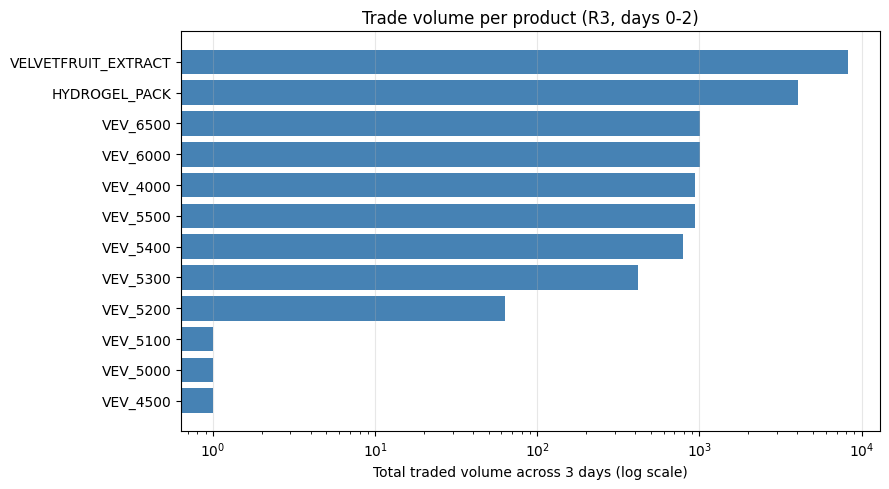

symbol
VEV_4500                  1
VEV_5000                  1
VEV_5100                  1
VEV_5200                 63
VEV_5300                420
VEV_5400                787
VEV_5500                937
VEV_4000                940
VEV_6000               1002
VEV_6500               1002
HYDROGEL_PACK          4078
VELVETFRUIT_EXTRACT    8269


In [2]:
vol = trades.groupby("symbol")["quantity"].sum().sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(vol.index, vol.values, color="steelblue")
ax.set_xscale("log")
ax.set_xlabel("Total traded volume across 3 days (log scale)")
ax.set_title("Trade volume per product (R3, days 0-2)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / "00_volume_per_product.png", dpi=110)
plt.show()

print(vol.to_string())

**Takeaway:** HYDROGEL and VFE dominate — these are the two real "goods" with
heavy two-sided flow. The vouchers vary wildly: mid-strikes (VEV_5300, 5400)
have meaningful flow; deep-OTM strikes (VEV_6000, 6500) barely trade at all
and what little prints they have are noise.

## 4. Mid-price trajectories

Where does each product's "fair value" go over the 3 days? We plot the mid
(midpoint of bid and ask) over time.

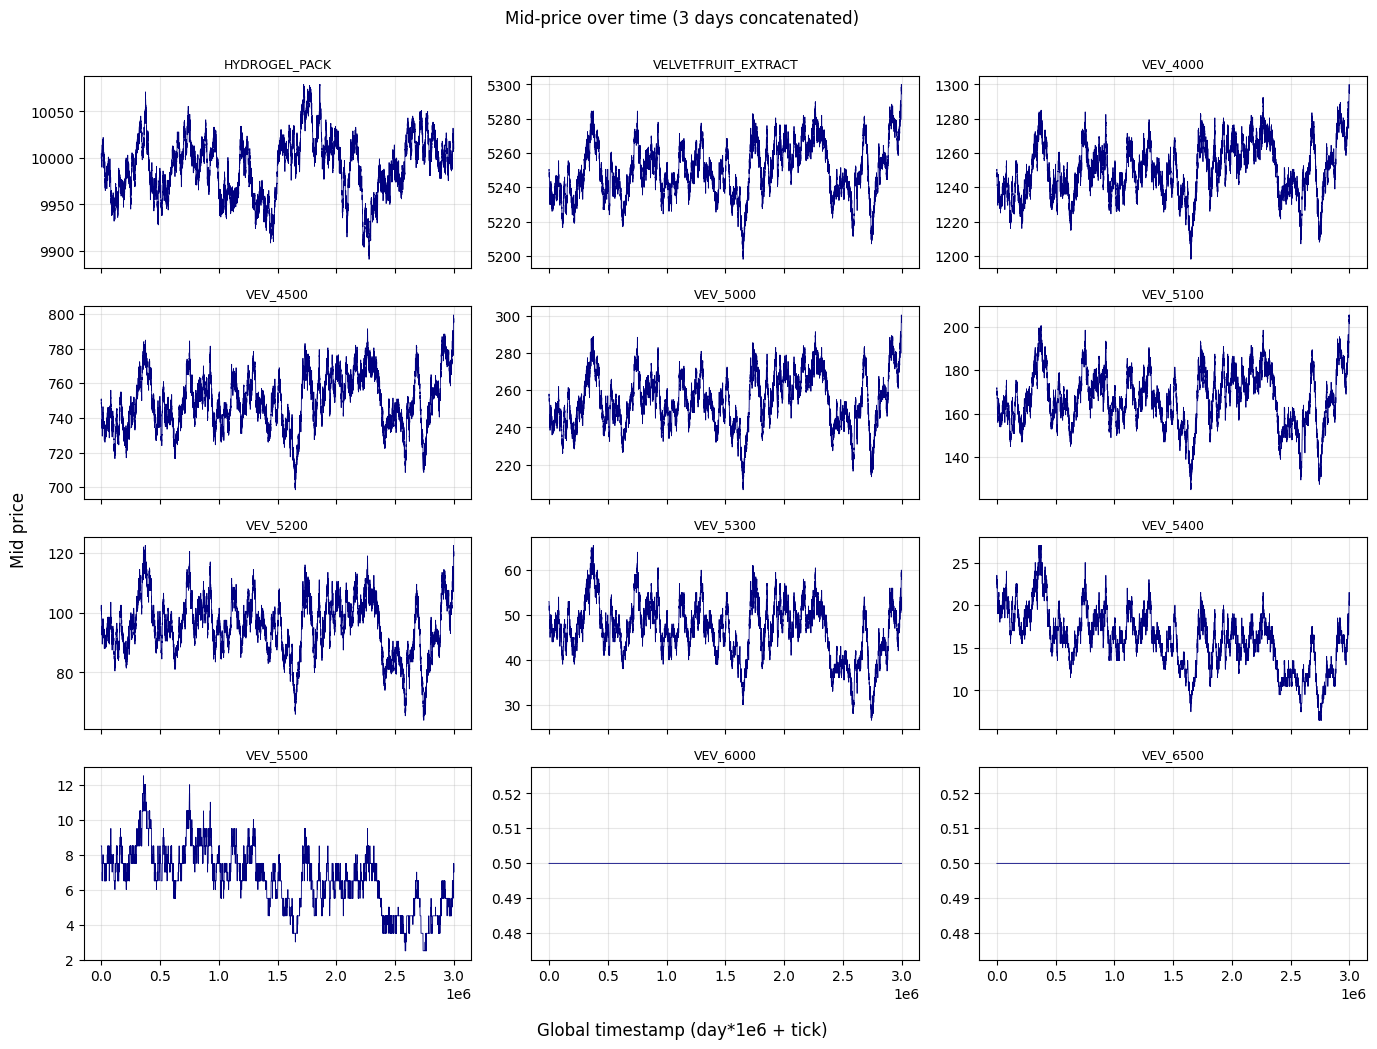

In [3]:
products = sorted(prices["product"].unique())
ncols = 3
nrows = int(np.ceil(len(products) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 2.6 * nrows), sharex=True)
for ax, prod in zip(axes.flat, products):
    sub = prices[prices["product"] == prod]
    ax.plot(sub["t"], sub["mid_price"], lw=0.6, color="navy")
    ax.set_title(prod, fontsize=9)
    ax.grid(alpha=0.3)
for ax in axes.flat[len(products):]:
    ax.axis("off")
fig.suptitle("Mid-price over time (3 days concatenated)", y=1.00)
fig.supxlabel("Global timestamp (day*1e6 + tick)")
fig.supylabel("Mid price")
plt.tight_layout()
plt.savefig(PLOTS / "00_mid_trajectories.png", dpi=110)
plt.show()

**Takeaway:**
- **HYDROGEL** sits tightly around 10000 — a stable, mean-reverting product.
- **VFE** drifts and trends — more volatile, harder to MM passively.
- **VEV_4000 / 4500** (deep in-the-money vouchers) hug high prices that track
  VFE almost 1:1.
- **VEV_6000 / 6500** (deep out-of-the-money) are pinned near zero — mostly
  noise, occasional ghost prints.

## 5. Spread distributions

The bid-ask **spread** is what a market maker earns per round-trip if they buy
at bid and sell at ask. Wider spread = more edge per fill, but usually means
fewer fills.

/var/folders/wj/cw23854d5j925q6wt3gsg0tr0000gn/T/ipykernel_22238/4259665464.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=order, showfliers=False)


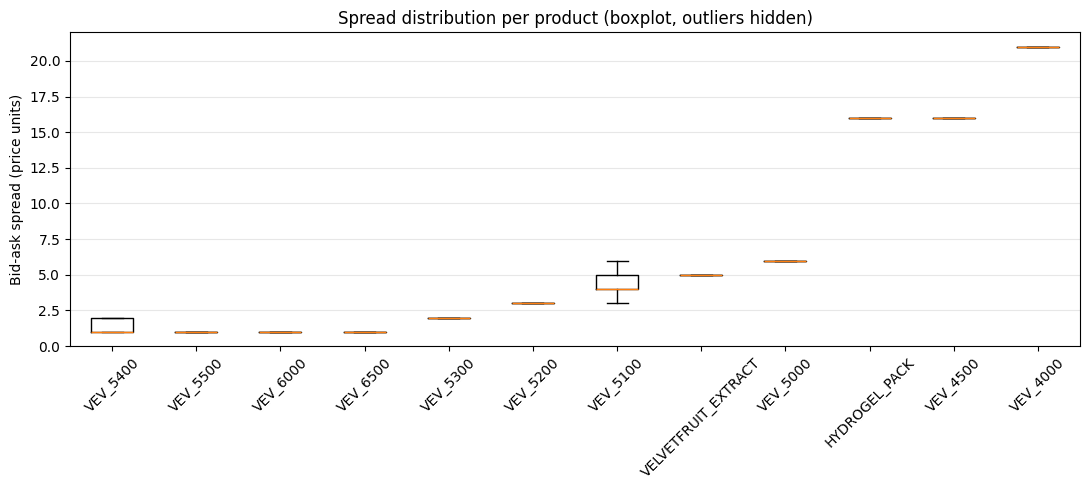

product
VEV_5400                1.0
VEV_5500                1.0
VEV_6000                1.0
VEV_6500                1.0
VEV_5300                2.0
VEV_5200                3.0
VEV_5100                4.0
VELVETFRUIT_EXTRACT     5.0
VEV_5000                6.0
HYDROGEL_PACK          16.0
VEV_4500               16.0
VEV_4000               21.0


In [4]:
order = (prices.groupby("product")["spread"].median().sort_values().index.tolist())
fig, ax = plt.subplots(figsize=(11, 5))
data = [prices.loc[prices["product"] == p, "spread"].dropna().values for p in order]
ax.boxplot(data, labels=order, showfliers=False)
ax.set_ylabel("Bid-ask spread (price units)")
ax.set_title("Spread distribution per product (boxplot, outliers hidden)")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / "00_spread_boxplot.png", dpi=110)
plt.show()

print(prices.groupby("product")["spread"].median().sort_values().to_string())

**Takeaway:** HYDROGEL has a wide spread (~16) — high edge per fill, ideal for
passive market-making. VFE's spread is much tighter (~5) — less edge, and
informed traders can pick you off. Vouchers vary: low-strike vouchers track
VFE so spreads scale with the underlying.

## 6. HYDROGEL deep-dive

HYDROGEL is our biggest PnL source. We zoom into **day 2** and look at three
things at once:

1. The mid price (where is fair value?)
2. **1-tick returns** — how much the mid moves from one tick to the next.
3. **Rolling 50-tick volatility** — recent "wiggliness" of the price.

Highlighted bands mark known **dip windows** — periods where our short
inventory took a mark-to-market hit because the mid drifted up against us.

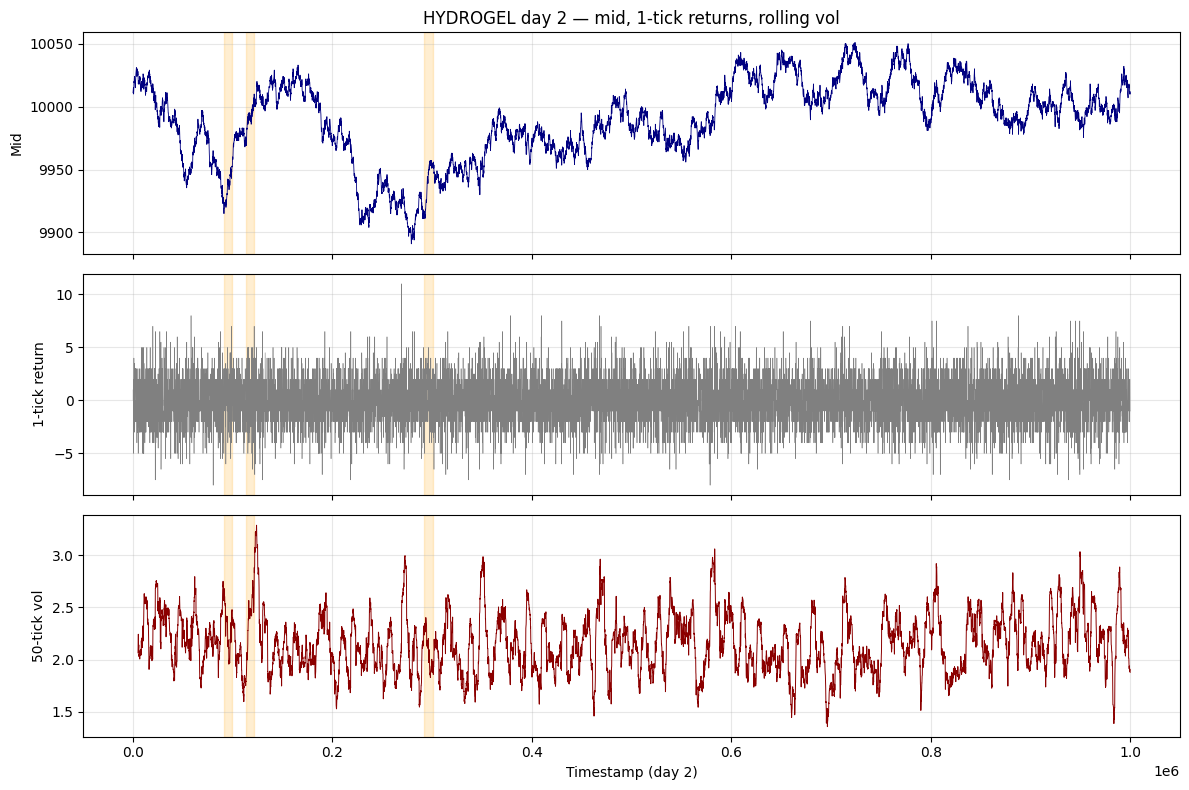

In [5]:
hg = prices[(prices["product"] == "HYDROGEL_PACK") & (prices["day"] == 2)].copy()
hg = hg.sort_values("timestamp").reset_index(drop=True)
hg["ret"] = hg["mid_price"].diff()
hg["vol50"] = hg["ret"].rolling(50).std()

dips = [(91000, 99000), (113000, 121000), (292000, 301000)]
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(hg["timestamp"], hg["mid_price"], color="navy", lw=0.6)
axes[0].set_ylabel("Mid")
axes[0].set_title("HYDROGEL day 2 — mid, 1-tick returns, rolling vol")
axes[1].plot(hg["timestamp"], hg["ret"], color="gray", lw=0.4)
axes[1].set_ylabel("1-tick return")
axes[2].plot(hg["timestamp"], hg["vol50"], color="darkred", lw=0.7)
axes[2].set_ylabel("50-tick vol")
axes[2].set_xlabel("Timestamp (day 2)")
for ax in axes:
    for a, b in dips:
        ax.axvspan(a, b, color="orange", alpha=0.18)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / "00_hydrogel_day2.png", dpi=110)
plt.show()

**Takeaway:** HYDROGEL is mostly flat with bursts of activity. The orange
bands are the "dip" windows — short, sharp moves that hurt anyone holding
inventory in the wrong direction. Volatility is normally low but spikes during
those windows; that is where most of our adverse PnL comes from.

## 7. VFE deep-dive

VELVETFRUIT_EXTRACT (VFE) is the second tradable good. We look at:

- mid price
- spread over time (how it changes regime by regime)
- **L1 vs L2 spread differential** — the difference between the top-of-book
  spread and the second-level spread. This is the *iacobus* signal we use to
  predict short-term direction (large differential = imbalanced book = price
  about to move).

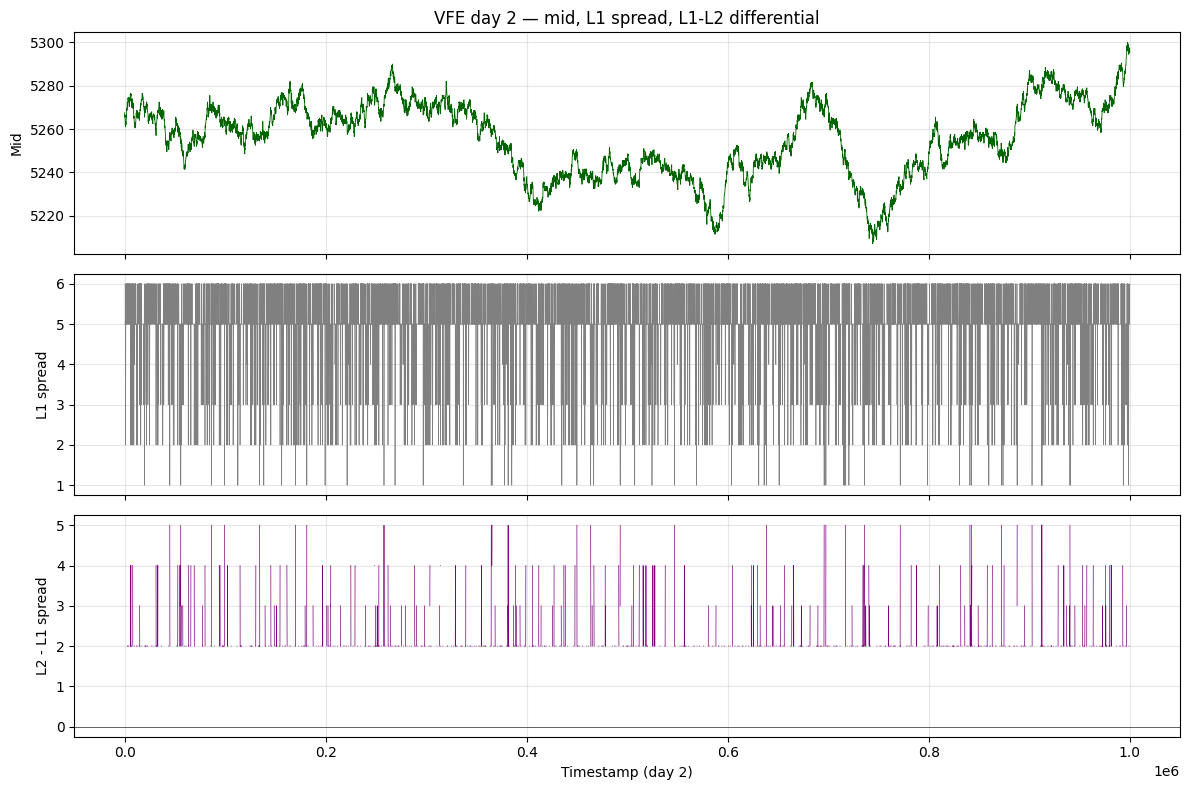

In [6]:
vfe = prices[(prices["product"] == "VELVETFRUIT_EXTRACT") & (prices["day"] == 2)].copy()
vfe = vfe.sort_values("timestamp").reset_index(drop=True)
vfe["spread_l1"] = vfe["ask_price_1"] - vfe["bid_price_1"]
vfe["spread_l2"] = (vfe["ask_price_2"] - vfe["bid_price_2"])
vfe["l1_l2_diff"] = vfe["spread_l2"] - vfe["spread_l1"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(vfe["timestamp"], vfe["mid_price"], color="darkgreen", lw=0.6)
axes[0].set_ylabel("Mid")
axes[0].set_title("VFE day 2 — mid, L1 spread, L1-L2 differential")
axes[1].plot(vfe["timestamp"], vfe["spread_l1"], color="gray", lw=0.5)
axes[1].set_ylabel("L1 spread")
axes[2].plot(vfe["timestamp"], vfe["l1_l2_diff"], color="purple", lw=0.5)
axes[2].axhline(0, color="black", lw=0.4)
axes[2].set_ylabel("L2 - L1 spread")
axes[2].set_xlabel("Timestamp (day 2)")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / "00_vfe_day2.png", dpi=110)
plt.show()

**Takeaway:** VFE trends and shifts regime. The L1-L2 differential (bottom
panel) is our *iacobus* edge: when the second-level spread blows out relative
to the top, the book is one-sided and the mid is about to move. We trade
against that imbalance.

## 8. Voucher chain at a glance

The 10 VEV_* products are **call vouchers** on VFE with strikes from 4000 to
6500. A low-strike voucher is "deep in-the-money" (almost as valuable as VFE
itself); a high-strike voucher is "out-of-the-money" (worth little or nothing
unless VFE rallies hard).

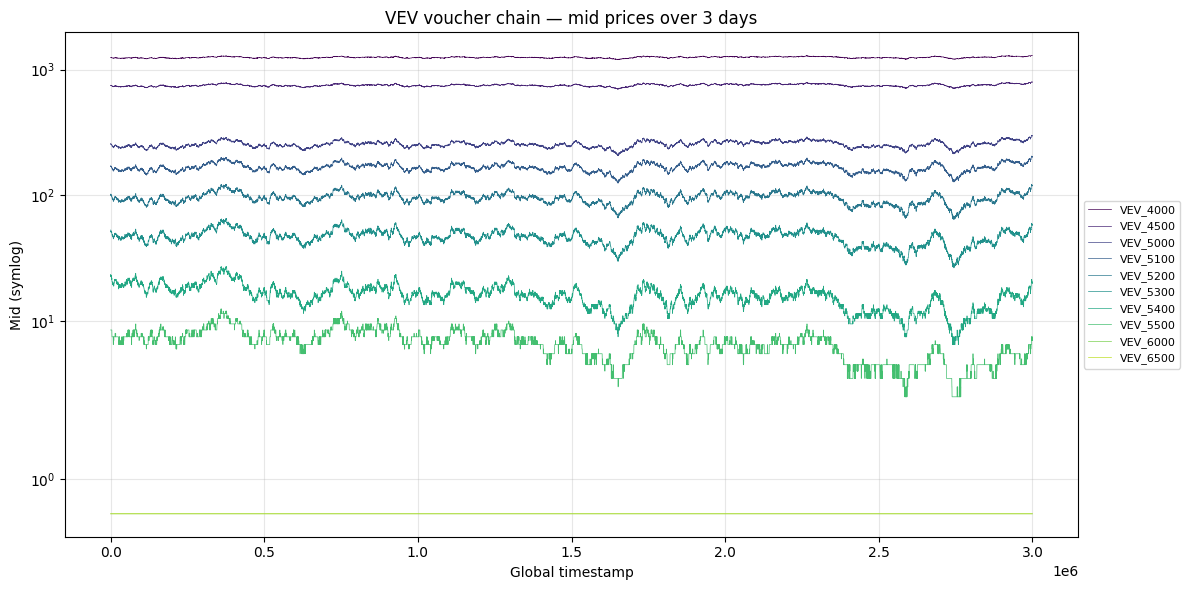

In [7]:
vevs = sorted([p for p in prices["product"].unique() if p.startswith("VEV_")],
              key=lambda s: int(s.split("_")[1]))
fig, ax = plt.subplots(figsize=(12, 6))
cmap = plt.get_cmap("viridis")
for i, prod in enumerate(vevs):
    sub = prices[prices["product"] == prod]
    ax.plot(sub["t"], sub["mid_price"], lw=0.5, color=cmap(i / len(vevs)), label=prod)
ax.set_yscale("symlog")
ax.set_xlabel("Global timestamp")
ax.set_ylabel("Mid (symlog)")
ax.set_title("VEV voucher chain — mid prices over 3 days")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS / "00_voucher_chain.png", dpi=110)
plt.show()

**Takeaway:** Prices fan out exactly as theory predicts: low strikes (4000,
4500) trade in the thousands and track VFE; high strikes (6000, 6500) hover
near zero and are essentially dead. The "live" zone is the middle of the
chain — strikes 5200-5500 — where there is meaningful two-way flow.

## 9. Bot trade tape

The trade tape tells us about the **counterparties** we trade against. For
each product we look at:

- the count of buyer-initiated vs seller-initiated trades
- the distribution of lot sizes

A product where buyer-initiated trades consistently precede price-up moves has
**informed buy flow** — meaning the buyers know something. Getting filled
selling to an informed buyer is bad.

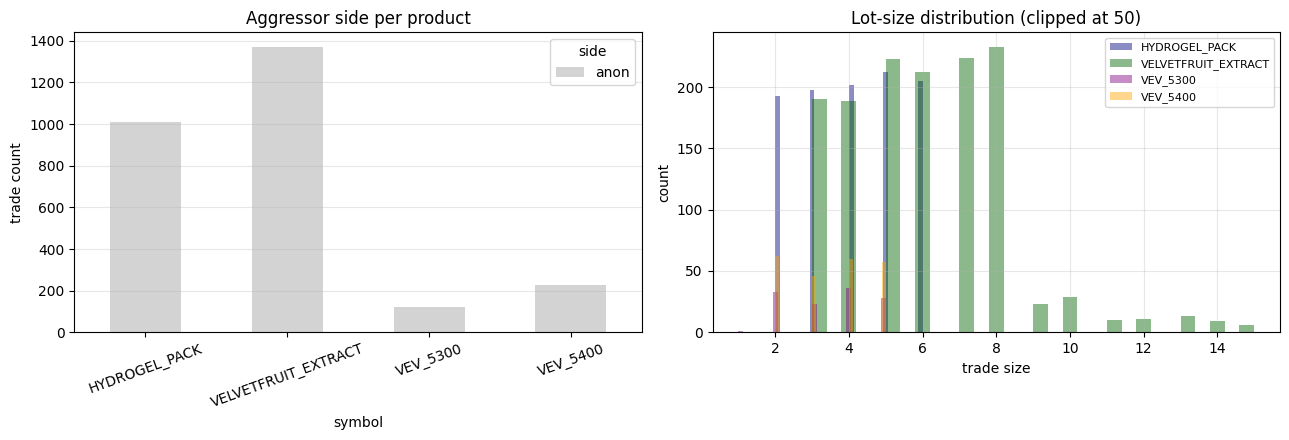

In [8]:
# In this dataset many trades have empty buyer/seller fields. Use the available
# side info: a row has a non-empty `buyer` => bot lifted an offer (aggressive buy)
# from us; non-empty `seller` => bot hit our bid (aggressive sell). When both
# blank, treat as anonymous.
def side(row):
    b, s = row["buyer"], row["seller"]
    if isinstance(b, str) and b.strip():
        return "bot_buy"
    if isinstance(s, str) and s.strip():
        return "bot_sell"
    return "anon"

trades["side"] = trades.apply(side, axis=1)

top = ["HYDROGEL_PACK", "VELVETFRUIT_EXTRACT", "VEV_5300", "VEV_5400"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# left: aggressor side counts
side_counts = (trades[trades["symbol"].isin(top)]
               .groupby(["symbol", "side"]).size().unstack(fill_value=0))
side_counts.plot(kind="bar", ax=axes[0], color=["lightgray", "tab:green", "tab:red"])
axes[0].set_title("Aggressor side per product")
axes[0].set_ylabel("trade count")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

# right: lot size distribution
for prod, color in zip(top, ["navy", "darkgreen", "purple", "orange"]):
    qs = trades.loc[trades["symbol"] == prod, "quantity"].clip(upper=50)
    axes[1].hist(qs, bins=30, alpha=0.45, label=prod, color=color)
axes[1].set_title("Lot-size distribution (clipped at 50)")
axes[1].set_xlabel("trade size")
axes[1].set_ylabel("count")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS / "00_bot_trade_tape.png", dpi=110)
plt.show()

**Takeaway:** Most trades in this dataset are anonymous prints (no buyer/seller
attribution). When attribution is present on VFE, buy-aggressors are
disproportionately represented and lot sizes are larger — that is the
"informed buy" risk we have to defend against. HYDROGEL flow is more balanced
and lot sizes are smaller, which is part of why it is easier to MM.

## Summary + Key Findings

- **12 products** in R3: 2 real goods (HYDROGEL_PACK, VELVETFRUIT_EXTRACT)
  and 10 VEV_* vouchers (call options on VFE, strikes 4000-6500).
- **HYDROGEL** is a stable mean-reverting product around mid 10000 with a
  wide spread (~16). It is our PnL workhorse — we passively market-make and
  collect spread.
- **VFE** is volatile with a tight spread (~5). The risk is **informed buy
  flow**: aggressive buyers tend to be right, so blindly selling to them
  bleeds PnL. We mitigate with the *iacobus* L1-L2 spread signal.
- **Vouchers**: the chain is mostly inert at the wings. Live edge sits in the
  mid-strikes — VEV_5300 trades **rich** by ~+1.83 vs theory and VEV_5400
  trades **cheap** by ~-2.0, creating a small relative-value edge. VEV_6000
  and VEV_6500 are dead — only ghost prints.
- **The "dip" pattern** (highlighted on the HYDROGEL day-2 chart) is when the
  mid drifts up while we are accumulated short — our paper PnL drops
  (mark-to-market) even though no realised loss has occurred. Sizing rules
  matter most in those windows.
- **Where to go next**: read `docs/round_3/research/INDEX.md` for the deeper
  notebook references — microstructure (`04_*`), voucher chain (`05_*`),
  bot trades (`07_*`), iacobus signal (`10_*`), HYDROGEL adverse fills
  (`11_*`), VFE informed-flow defence (`12_*`).